# Bayesian Bootstrap for Paired Binary Outcomes

The **Bayesian bootstrap** (Rubin, 1981) is a nonparametric method for posterior inference that avoids specifying a parametric likelihood. Instead of resampling observations (as in the classical bootstrap), it draws random **Dirichlet weights** over the observed data.

## Setup

For paired binary observations $(y_{A,i}, y_{B,i})$, define the paired difference

$$D_i = y_{A,i} - y_{B,i}, \quad D_i \in \{-1, 0, +1\}.$$

Each posterior draw of the average treatment effect is

$$
\Delta^{(s)} = \sum_{i=1}^{n} w_i^{(s)}\, D_i,
\qquad
\mathbf{w}^{(s)} \sim \text{Dirichlet}(\alpha,\dots,\alpha)
$$

with $\alpha = 1$ the standard noninformative choice. The class `PairedBayesPropTestBB` exposes this procedure with the same API surface as the parametric paired tests (`PairedBayesPropTest` Laplace, `PairedBayesPropTestPG` Pólya–Gamma), minus the Savage–Dickey BF (which has no nonparametric analogue — see the [guide page](https://avoss84.github.io/bayesProp/guide/paired_bootstrap/) for details).

This notebook doubles as an integration test of the public API.

## 1. Imports

θ_A = 0.7166,  θ_B = 0.3849
Mean Δ (θ_A − θ_B) = +0.3317
95% CI = [0.0908, 0.5483]
P(A > B) = 0.9960

--- Unified Decision ---
  Bayes Factor: BF₁₀ = 17.73  → Reject H0
  Posterior Null: P(H₀|D) = 0.0534  → Undecided
  ROPE: Reject H0 — A practically better (0.4% in ROPE)


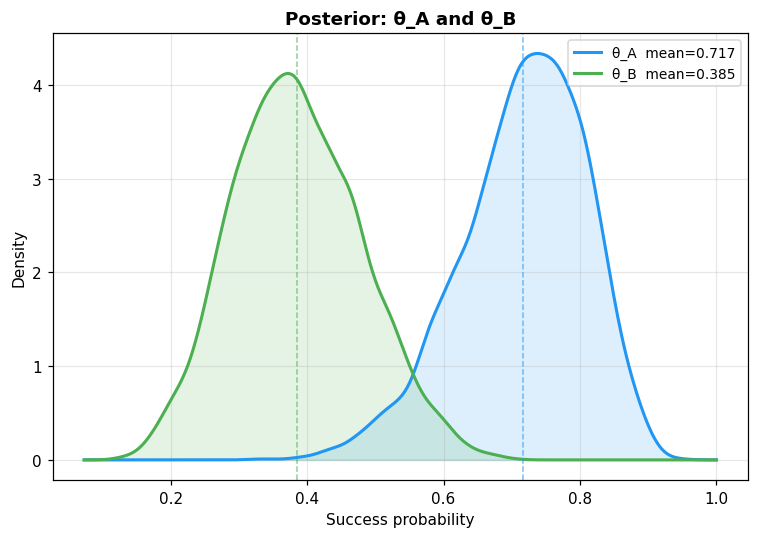

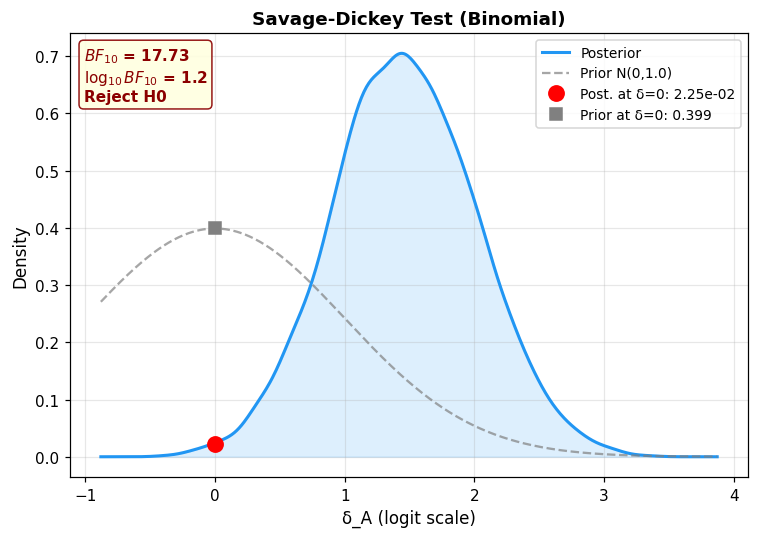

In [5]:
import numpy as np
from bayesprop.resources.bayes_paired_laplace import PairedBayesPropTest

# Paired binary data (y_A[i] and y_B[i] refer to the same item)
y_A = np.array([1,1,0,1,1,0,1,1,1,1,1,1,1,0,1,1,1,0,1,1])     # 16/20 = 0.80
y_B = np.array([0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0])     #  6/20 = 0.30

# Fit posterior & summarise
model = PairedBayesPropTest(seed=42).fit(y_A, y_B)

s = model.summary
print(f"θ_A = {s.theta_A_mean:.4f},  θ_B = {s.theta_B_mean:.4f}")
print(f"Mean Δ (θ_A − θ_B) = {s.mean_delta:+.4f}")
print(f"95% CI = [{s.ci_95.lower:.4f}, {s.ci_95.upper:.4f}]")
print(f"P(A > B) = {s.p_A_greater_B:.4f}")

# ── Unified decision ─────────────────────────────────────────────────
d = model.decide()
bf = d.bayes_factor

print("\n--- Unified Decision ---")
print(f"  Bayes Factor: BF₁₀ = {bf.BF_10:.2f}  → {bf.decision}")
print(f"  Posterior Null: P(H₀|D) = {d.posterior_null.p_H0:.4f}  → {d.posterior_null.decision}")
print(f"  ROPE: {d.rope.decision} ({d.rope.pct_in_rope:.1%} in ROPE)")

# Plots
model.plot_posteriors()
model.plot_savage_dickey()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


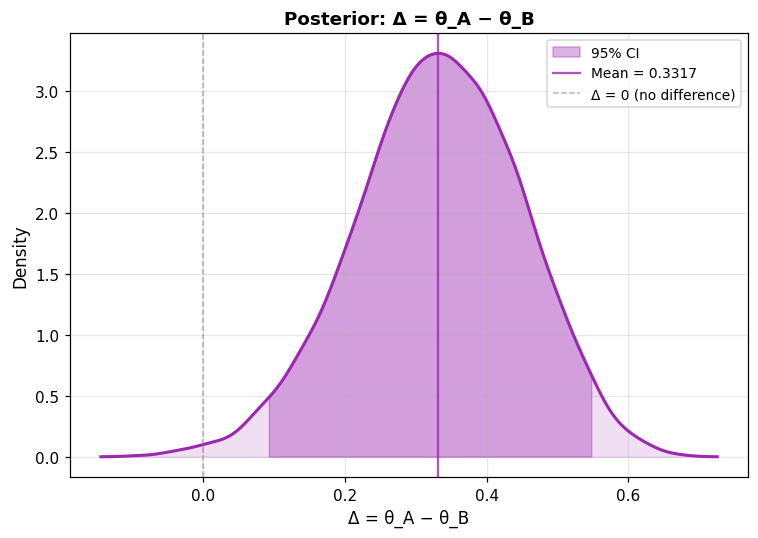

In [6]:
from __future__ import annotations

%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from bayesprop.resources.bayes_paired_bootstrap import PairedBayesPropTestBB

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
model.plot_posterior_delta()

## 2. Paired binary observations

In [7]:
# Example paired binary observations.
# y_B (= "before") is the baseline arm; y_A (= "after") is the treatment arm.
y_B = np.array([0, 1, 1, 0, 1, 0, 0, 1, 1, 0])
y_A = np.array([1, 1, 0, 1, 1, 0, 1, 1, 0, 1])

print(f"Number of paired observations: {len(y_A)}")
print(f"y_B (before): {y_B}")
print(f"y_A (after):  {y_A}")
print(f"Paired differences D_i = y_A − y_B: {y_A - y_B}")

Number of paired observations: 10
y_B (before): [0 1 1 0 1 0 0 1 1 0]
y_A (after):  [1 1 0 1 1 0 1 1 0 1]
Paired differences D_i = y_A − y_B: [ 1  0 -1  1  0  0  1  0 -1  1]


## 3. Fit the Bayesian-bootstrap posterior

We use the public class `PairedBayesPropTestBB`. Behind the scenes, `fit(y_A, y_B)` draws all 20 000 weight vectors in a single vectorised `rng.dirichlet` call and computes the posterior on $\Delta = p_A - p_B$ with one matmul against the per-pair differences.

In [8]:
model = PairedBayesPropTestBB(n_samples=20_000, seed=123, rope_epsilon=0.05).fit(y_A, y_B)
model

PairedBayesPropTestBB(n_samples=20000, seed=123)
  θ_A = 0.7000,  θ_B = 0.5000
  Mean Δ = +0.2010,  95% CI = [-0.2622, 0.6237]
  P(A > B) = 0.8154

## 4. Posterior summary statistics

`.summary` is a `PairedSummary` Pydantic model exposing the posterior mean of $\Delta$, the 95 % equal-tailed credible interval, and $P(A > B)$ on the probability scale.

In [9]:
s = model.summary
print("Bayesian Bootstrap — paired binary data")
print("-" * 55)
print(f"θ_A posterior mean:      {s.theta_A_mean:.4f}")
print(f"θ_B posterior mean:      {s.theta_B_mean:.4f}")
print(f"Posterior mean Δ:        {s.mean_delta:+.4f}")
print(f"95% credible interval:   [{s.ci_95.lower:+.4f}, {s.ci_95.upper:+.4f}]")
print(f"P(A > B):                {s.model_dump(by_alias=True)['P(A > B)']:.4f}")
print()
print("trace_summary:")
print(model.trace_summary)

Bayesian Bootstrap — paired binary data
-------------------------------------------------------
θ_A posterior mean:      0.7000
θ_B posterior mean:      0.5000
Posterior mean Δ:        +0.2010
95% credible interval:   [-0.2622, +0.6237]
P(A > B):                0.8154

trace_summary:
          mean        sd   hdi_3%   hdi_97%
delta  0.20098  0.225689 -0.24334  0.609218


## 5. Visualise the posterior

The class ships a built-in `plot_posterior` helper that overlays the posterior mean, the 95 % CI band, and the configured ROPE on a single histogram.

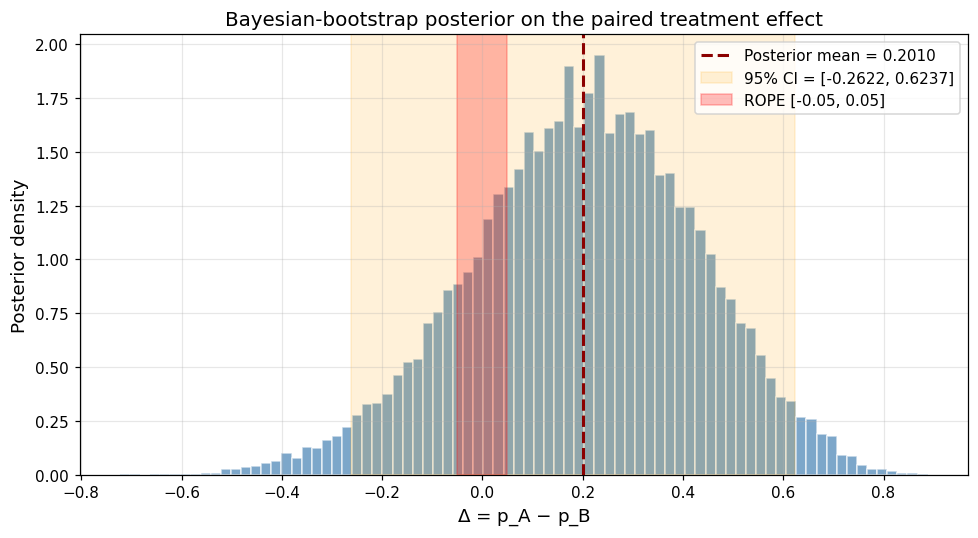

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
model.plot_posterior(rope=(-0.05, 0.05), ax=ax)
plt.tight_layout()
plt.show()

## 6. Sensitivity to `n_samples`

Posterior summaries should stabilise as `n_samples` grows. The CI width converges to its true frequentist 95 % posterior interval and $P(A > B)$ converges to its true posterior probability.

In [11]:
sample_sizes = [1_000, 5_000, 10_000, 20_000, 50_000]
print(f"{'n_samples':>10}  {'mean Δ':>10}  {'95% CI width':>14}  {'P(A>B)':>8}")
print("-" * 50)
for n in sample_sizes:
    m = PairedBayesPropTestBB(n_samples=n, seed=42).fit(y_A, y_B)
    ci = m.summary.ci_95
    p_a_gt_b = m.summary.model_dump(by_alias=True)["P(A > B)"]
    print(f"{n:>10,}  {m.summary.mean_delta:>+10.4f}  "
          f"{ci.upper - ci.lower:>14.4f}  {p_a_gt_b:>8.4f}")

 n_samples      mean Δ    95% CI width    P(A>B)
--------------------------------------------------
     1,000     +0.1953          0.9523    0.8150
     5,000     +0.1968          0.8940    0.8120
    10,000     +0.2009          0.8960    0.8144
    20,000     +0.1985          0.8858    0.8101
    50,000     +0.1996          0.8799    0.8113


## 7. Sensitivity to `dirichlet_alpha`

The standard Bayesian bootstrap uses $\alpha = 1$ (flat Dirichlet on the simplex). Values $\alpha < 1$ concentrate weight on a small subset of observations (sharper, more bootstrap-like, wider posterior); values $\alpha > 1$ smooth toward the empirical mean and shrink the CI. The posterior mean is essentially invariant — only the spread changes.

In [12]:
alphas = [0.25, 0.5, 1.0, 2.0, 5.0]
print(f"{'α':>6}  {'mean Δ':>10}  {'95% CI':>26}  {'CI width':>10}")
print("-" * 60)
for alpha in alphas:
    m = PairedBayesPropTestBB(
        n_samples=20_000, seed=42, dirichlet_alpha=alpha
    ).fit(y_A, y_B)
    ci = m.summary.ci_95
    print(f"{alpha:>6.2f}  {m.summary.mean_delta:>+10.4f}  "
          f"[{ci.lower:>+8.4f}, {ci.upper:>+8.4f}]  {ci.upper - ci.lower:>10.4f}")

     α      mean Δ                      95% CI    CI width
------------------------------------------------------------
  0.25     +0.1953  [ -0.6628,  +0.8885]      1.5513
  0.50     +0.2013  [ -0.4255,  +0.7495]      1.1750
  1.00     +0.1985  [ -0.2640,  +0.6219]      0.8858
  2.00     +0.1996  [ -0.1329,  +0.5142]      0.6471
  5.00     +0.2002  [ -0.0116,  +0.3995]      0.4112


## 8. Decision API — ROPE only

The Bayesian bootstrap does **not** support a Savage–Dickey Bayes factor (there is no parametric prior on $\Delta$ to evaluate at the null), and we deliberately do not synthesise a prior-weighted `posterior_probability_H0` either — under the BB the three quantities of interest are well-defined directly off the posterior:

1. **Posterior of null** — $P(\Delta \in \text{ROPE} \mid \text{data})$, exposed as `rope_test().pct_in_rope`.
2. **Posterior of superiority** — $P(p_A > p_B \mid \text{data})$, exposed as `model.summary.p_A_greater_B`.
3. **ROPE decision** (reject / accept / undecided), exposed as `rope_test().decision`.

The composite `decide()` returns a `HypothesisDecision` whose `rope` sub-field is populated and whose `bayes_factor` / `posterior_null` sub-fields are always `None`. See the [guide page](https://avoss84.github.io/bayesProp/guide/paired_bootstrap/#decision-api) for the full design rationale.

In [13]:
rope = (-0.05, 0.05)

# (1) Posterior of null + ROPE decision
r = model.rope_test(rope=rope)
print("ROPE analysis")
print("-" * 55)
print(f"ROPE:                     [{rope[0]}, {rope[1]}]")
print(f"95% CI on Δ:              [{r.ci_lower:+.4f}, {r.ci_upper:+.4f}]")
print(f"P(Δ ∈ ROPE | data):       {r.pct_in_rope:.4f}   ← posterior of null")
print(f"P(Δ < ROPE | data):       {r.pct_below_rope:.4f}")
print(f"P(Δ > ROPE | data):       {r.pct_above_rope:.4f}")
print(f"Decision:                 {r.decision}")

print()
# (2) Posterior of superiority — straight off the fitted summary
print("Posterior of superiority")
print("-" * 55)
print(f"P(p_A > p_B | data):      {model.summary.p_A_greater_B:.4f}")

print()
# (3) Composite decision — only the ROPE sub-result is populated.
d = model.decide()
print("Composite decision")
print("-" * 55)
print(f"rule:                     {d.rule}")
print(f"bayes_factor:             {d.bayes_factor}  ← always None for BB")
print(f"posterior_null:           {d.posterior_null}  ← always None for BB")
print(f"rope.decision:            {d.rope.decision}")

ROPE analysis
-------------------------------------------------------
ROPE:                     [-0.05, 0.05]
95% CI on Δ:              [-0.2622, +0.6237]
P(Δ ∈ ROPE | data):       0.1093   ← posterior of null
P(Δ < ROPE | data):       0.1370
P(Δ > ROPE | data):       0.7537
Decision:                 Undecided — CI overlaps ROPE

Posterior of superiority
-------------------------------------------------------
P(p_A > p_B | data):      0.8154

Composite decision
-------------------------------------------------------
rule:                     rope
bayes_factor:             None  ← always None for BB
posterior_null:           None  ← always None for BB
rope.decision:            Undecided — CI overlaps ROPE


In [14]:
# The BB class deliberately does not expose Bayes-factor-style methods.
for method_name in ("savage_dickey_test", "posterior_probability_H0"):
    print(f"hasattr(model, {method_name!r}):", hasattr(model, method_name))

hasattr(model, 'savage_dickey_test'): False
hasattr(model, 'posterior_probability_H0'): False


## 9. Contrast — parametric paired test (Laplace)

As a sanity check we fit the same paired data with the parametric Laplace-approximation paired test ([`PairedBayesPropTest`](https://avoss84.github.io/bayesProp/api/bayes_paired_laplace/)) — the default / canonical parametric paired class — and contrast its decision surface against the nonparametric Bayesian bootstrap above.

The Laplace model is the parametric counterpart of the BB for paired Bernoulli data: a logit-scale random effect $\delta_A \sim \mathcal{N}(0, \sigma_\delta^2)$ and a baseline $\mu \sim \mathcal{N}(0, \sigma_\mu^2)$, with a Gaussian approximation to the joint posterior around the MAP. Unlike the BB it does admit a Savage–Dickey BF at the point null $\delta_A = 0$, so we get **four** decision lenses we can compare:

| Lens | BB (nonparametric) | Laplace (parametric) |
|---|---|---|
| Posterior of null, $P(\Delta \in \text{ROPE})$ | ✅ `rope_test().pct_in_rope` | ✅ `rope_test().pct_in_rope` |
| Posterior of superiority, $P(p_A > p_B)$ | ✅ `summary.p_A_greater_B` | ✅ `summary.p_A_greater_B` |
| ROPE decision | ✅ `rope_test().decision` | ✅ `rope_test().decision` |
| Savage–Dickey BF at $\delta_A = 0$ | ❌ not exposed | ✅ `savage_dickey_test().BF_10` |

Where the two procedures *disagree* is informative: at small $n$ the Gaussian prior on $\delta_A$ shrinks the posterior toward the null, so its ROPE mass typically sits higher than the BB's flat-Dirichlet posterior. The BB, by contrast, mirrors the empirical distribution more aggressively. At larger $n$ both converge to the same posterior on $\Delta$.

Why Laplace and not Pólya–Gamma here? At this $n$ the two parametric posteriors agree to within MC noise, but Laplace is ~50× faster (single Newton step vs. 4 MCMC chains), and it's the class used throughout the rest of the documentation — including the [paired frequentist-evaluation notebook](https://avoss84.github.io/bayesProp/guide/frequentist_evaluation_paired/). Use `PairedBayesPropTestPG` instead if you want the exact MCMC posterior — see [its guide page](https://avoss84.github.io/bayesProp/guide/paired_pg/).

In [15]:
from bayesprop.resources.bayes_paired_laplace import PairedBayesPropTest

# Same paired data, same ROPE, same seed family.
lap = PairedBayesPropTest(
    prior_sigma_delta=1.0,
    n_samples=20_000,
    seed=123,
    rope_epsilon=0.05,
).fit(y_A, y_B)

# Decision sub-results from the parametric model.
lap_rope = lap.rope_test(rope=rope)
lap_sd = lap.savage_dickey_test(null_value=0.0)
lap_pn = PairedBayesPropTest.posterior_probability_H0(lap_sd.BF_01, prior_H0=0.5)

bb_rope = model.rope_test(rope=rope)

# ── Side-by-side report ──
LBL, COL = 42, 32  # label + per-model column widths
print(f"{'':{LBL}s}{'BB (nonparametric)':>{COL}s}{'Laplace (parametric)':>{COL}s}")
print("-" * (LBL + 2 * COL))
print(f"{'θ_A posterior mean':{LBL}s}"
      f"{model.summary.theta_A_mean:>+{COL}.4f}"
      f"{lap.summary.theta_A_mean:>+{COL}.4f}")
print(f"{'θ_B posterior mean':{LBL}s}"
      f"{model.summary.theta_B_mean:>+{COL}.4f}"
      f"{lap.summary.theta_B_mean:>+{COL}.4f}")
print(f"{'Posterior mean Δ':{LBL}s}"
      f"{model.summary.mean_delta:>+{COL}.4f}"
      f"{lap.summary.mean_delta:>+{COL}.4f}")
print(f"{'95% CI on Δ':{LBL}s}"
      f"{f'[{model.summary.ci_95.lower:+.3f}, {model.summary.ci_95.upper:+.3f}]':>{COL}s}"
      f"{f'[{lap.summary.ci_95.lower:+.3f}, {lap.summary.ci_95.upper:+.3f}]':>{COL}s}")
print(f"{'P(Δ ∈ ROPE | data)  (posterior of null)':{LBL}s}"
      f"{bb_rope.pct_in_rope:>{COL}.4f}"
      f"{lap_rope.pct_in_rope:>{COL}.4f}")
print(f"{'P(p_A > p_B | data) (superiority)':{LBL}s}"
      f"{model.summary.p_A_greater_B:>{COL}.4f}"
      f"{lap.summary.p_A_greater_B:>{COL}.4f}")
print(f"{'ROPE decision':{LBL}s}"
      f"{bb_rope.decision:>{COL}s}"
      f"{lap_rope.decision:>{COL}s}")
print(f"{'Savage–Dickey BF_10':{LBL}s}"
      f"{'— (n/a for BB)':>{COL}s}"
      f"{lap_sd.BF_10:>{COL}.3f}")
print(f"{'P(H₀ | data) from BF_01 + flat prior':{LBL}s}"
      f"{'— (n/a for BB)':>{COL}s}"
      f"{lap_pn.p_H0:>{COL}.4f}")

                                                        BB (nonparametric)            Laplace (parametric)
----------------------------------------------------------------------------------------------------------
θ_A posterior mean                                                 +0.7000                         +0.6440
θ_B posterior mean                                                 +0.5000                         +0.5391
Posterior mean Δ                                                   +0.2010                         +0.1049
95% CI on Δ                                               [-0.262, +0.624]                [-0.193, +0.393]
P(Δ ∈ ROPE | data)  (posterior of null)                             0.1093                          0.2011
P(p_A > p_B | data) (superiority)                                   0.8154                          0.7582
ROPE decision                                 Undecided — CI overlaps ROPE    Undecided — CI overlaps ROPE
Savage–Dickey BF_10                  

## How this fits with the rest of the package

| Question | Class to use |
|---|---|
| Need a Savage–Dickey BF for a point null | `PairedBayesPropTest` (Laplace) or `PairedBayesPropTestPG` (Pólya–Gamma) |
| Need sequential / early-stopping support | `SequentialPairedBayesPropTest` |
| Worried about likelihood misspecification | **`PairedBayesPropTestBB`** *(this notebook)* |
| Sample size ≤ 30 and prior elicitation is acceptable | `PairedBayesPropTestPG` |
| Sample size ≫ 100 and want a prior-free posterior on $\Delta$ | **`PairedBayesPropTestBB`** |

See the [guide page](https://avoss84.github.io/bayesProp/guide/paired_bootstrap/) for the full discussion, including when to prefer the parametric paired tests over the bootstrap.